# Advanced Artificial Intelligence Task 2: 
## Inference Example

In [ ]:
import sys
import os
import cv2
from matplotlib import pyplot as plt
import numpy as np
from safetensors.torch import load_file
import torch
import random
import torch.nn as nn
from torchvision.models import get_model, get_weight
from PIL import Image
from pathlib import Path
import pickle
sys.path.append("..")
sys.path.append(".")
from utils.xai_wrapper import TaskWrapper, swin_reshape_transform
from utils.mtl_model import MultiTaskClassifier
from utils.dataset import ProduceDataset
from utils.inference import classify_produce, grade_produce, InferenceContext
from experiment_configs import task_2_config_final as experiments
from pytorch_grad_cam import GradCAM

# Select experiment and trained weights path 
# TRAINED_MODEL_PATH = Path(".") / "models" / "best/EX2_SWIN_FINETUNE_44_20260424015207.safetensors"
# EXPERIMENT = experiments.EX2_SWIN_FINETUNE
TRAINED_MODEL_PATH = Path(".") / "models" / "best/EX6a_SWIN_FINETUNE_MTL_20260422201021.safetensors"
EXPERIMENT = experiments.EX6a_SWIN_FINETUNE_MTL
assert EXPERIMENT.display_name.lower() in TRAINED_MODEL_PATH.stem.lower(), \
        (f"Checkpoint '{TRAINED_MODEL_PATH.name}"
         f"doesn't match experiment '{EXPERIMENT.display_name}"
         )
PRODUCE_DATESET_PATH = Path(".") / "data" / "Fruit_And_Vegetable_Diseases_Dataset"
# Type threshold given the limited number of produce types
# Inputs below the threshold will be considered "Unknown"
TYPE_CONFIDENCE_THRESHOLD = 50


# Load empty model architecture (without pretrained weights)
# Build the same MTL wrapper used during training
PRETRAINED_MODEL = get_model(EXPERIMENT.architecture, weights=None)
produce_dataset = ProduceDataset(dataset_root_dir=PRODUCE_DATESET_PATH, 
                                 transform=None)

if EXPERIMENT.is_mtl:
    # MTL: instantiate custom MTL with auxillary produce type objective
    # Need num_types to match training - get from dataset
    model = MultiTaskClassifier(PRETRAINED_MODEL, 
                                num_produce_classes=produce_dataset.num_produce_types)
else:
    # STL: replace the final classifier for binary health classification
    head_attr = "classifier" if hasattr(PRETRAINED_MODEL, "classifier") else "head"
    head = getattr(PRETRAINED_MODEL, head_attr)
    if isinstance(head, nn.Sequential):
        head[-1] = nn.Linear(head[-1].in_features, 2)
    # Swin exposes .head (single Linear).
    elif isinstance(head, nn.Linear):
        setattr(PRETRAINED_MODEL, head_attr, nn.Linear(head.in_features, 2))
    else:
        raise ValueError(f"Unsupported STL classification_head: {type(head).__name__}")
    model = PRETRAINED_MODEL

# Load trained weights into the MTL wrapper
if os.path.splitext(TRAINED_MODEL_PATH)[1] == ".pth":
    model.load_state_dict(torch.load(TRAINED_MODEL_PATH, weights_only=True))
else: # Load as safetensor
    state_dict = load_file(TRAINED_MODEL_PATH)
    model.load_state_dict(state_dict)

# Send to device and set model to eval mode
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)
model.eval()

# Get transforms for inference input
pretrained_weights = get_weight(EXPERIMENT.weight_string)
auto_transforms = pretrained_weights.transforms()

# Define the target classes
health_names = ['Healthy', 'Rotten']
type_names = produce_dataset.produce_type_names

context = InferenceContext(
    model=model,
    device=device,
    auto_transforms=auto_transforms,
    is_mtl=EXPERIMENT.is_mtl,
    health_names=health_names,
    type_names=type_names,
    type_confidence_threshold=TYPE_CONFIDENCE_THRESHOLD,
)

[MTL] Detected head attr: '.head'  arch=SwinTransformer
[MTL] Original head:
Linear(in_features=768, out_features=1000, bias=True)
[MTL] Backbone+neck output shape: (1, 768)  (expected (1, 768))


In [ ]:
cam_wrapper = TaskWrapper(model, target_task='health').eval()
# target_layers = [cam_wrapper.base_model.backbone.features[-1]]
target_layers = [cam_wrapper.base_model.backbone.norm]
cam = GradCAM(model=cam_wrapper, 
              target_layers=target_layers, 
              reshape_transform=swin_reshape_transform)

print(type(cam_wrapper.base_model))                  # should be MultiTaskClassifier
print(hasattr(cam_wrapper.base_model, 'backbone'))   # True if the attribute exists
print(type(cam_wrapper.base_model.backbone))    

<class 'utils.mtl_model.MultiTaskClassifier'>
True
<class 'torchvision.models.swin_transformer.SwinTransformer'>


Health: Healthy (99.7%)
Type:   unknown (15.8%) (strawberry - 34.2 below threshold)

Health: Healthy (99.7%)
Type:   unknown (15.8%) (strawberry - 34.2 below threshold)



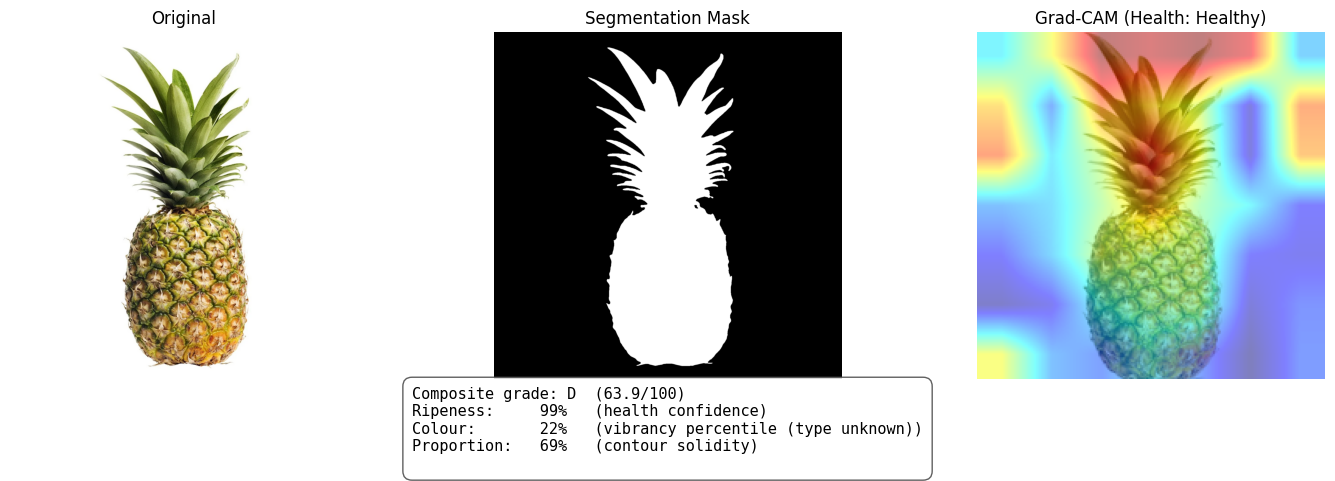

data/test_data/Pineapple.webp

Composite grade: D  (63.9/100)
Ripeness:     99%   (health confidence)
Colour:       22%   (vibrancy percentile (type unknown))
Proportion:   69%   (contour solidity)


In [ ]:
ood_test = False #overrides healthy and correct
show_healthy = False # Healthy predicitons only
show_correct = False # Find correct prediction

# Load references once
ref_path = Path(".") / "data" / "colour_references_rembg.pkl"
dist_path = Path(".") / "data" / "generic_colour_distribution.pkl"
rotten_ref_path = Path(".") / "data" / "colour_references_rembg_rotten.pkl"
with open(ref_path, "rb") as f:
    healthy_colour_refs = {k.lower(): v for k, v in pickle.load(f).items()}
with open(dist_path, "rb") as f:
    colour_distribution = {k.lower(): v for k, v in pickle.load(f).items()}
with open(rotten_ref_path, "rb") as f:
    rotten_refs = {k.lower(): v for k, v in pickle.load(f).items()}

while True:
    if ood_test:
        ood_test_image_dir = Path(".") / "data" / "test_data"
        images = [f for f in os.listdir(ood_test_image_dir)
                if f.lower().endswith(('.jpg', '.jpeg', '.png', '.webp'))]
        rdm_test_image = ood_test_image_dir / random.choice(images)
    else:
        test_img_dir = Path(".") / "data" / "golden_dataset2" / "golden_dataset2"
        rdm_class_dir = test_img_dir / random.choice(os.listdir(test_img_dir))
        rdm_test_image = rdm_class_dir / random.choice(os.listdir(rdm_class_dir))

    result = grade_produce(rdm_test_image, context, healthy_colour_refs, rotten_refs, colour_distribution,
                           preview_img=False, composite_result=True, softmax_g=5, cam=cam)

    type_ok = not show_correct or result.get("fruit_type") != "unknown"
    health_ok = not show_healthy or result.get("prediction") != "Rotten"

    if ood_test or (type_ok and health_ok):
        result = grade_produce(rdm_test_image, context, healthy_colour_refs, rotten_refs, colour_distribution,
                               grade_colour_vs_ref=True, preview_img=True, composite_result=True, softmax_g=5, cam=cam)
        break

print(rdm_test_image)
print("\n" + result['explanation'])